In [9]:
## import tensorflow
import tensorflow as tf

tf.__version__


'2.19.0'

In [10]:
## Load the mnist dataset
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()


len(x_test) ,len(x_train)

(10000, 60000)

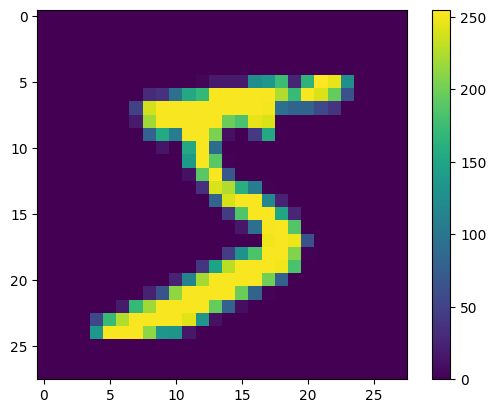

In [11]:
## visualize
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.colorbar()

In [12]:
y_train[0]

np.uint8(5)

In [13]:
x_train[0].shape , y_train[0].shape

((28, 28), ())

### Noramlize the data 

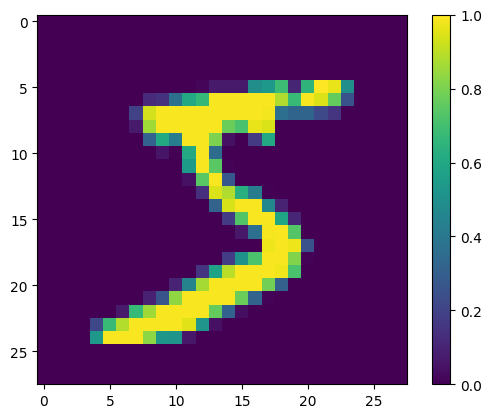

In [14]:
x_train = x_train/ 255.0
x_test = x_test/ 255.0

plt.imshow(x_train[0])
plt.colorbar()

In [32]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),         # Preferred input definition
    tf.keras.layers.Flatten(), ## it will convert 28*28  --> (1,784)
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
    
])



outs = model(tf.expand_dims(x_train[0], axis=0))
outs.numpy()

array([[ 0.16640882, -0.5475526 ,  0.21241102, -0.01083482,  0.18595535,
         0.37117147,  0.2228271 , -0.04437982,  0.7434095 , -0.53135276]],
      dtype=float32)

In [43]:
tf.nn.softmax(outs, axis=1)

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[0.10237827, 0.05013468, 0.1071979 , 0.08574954, 0.10439909,
        0.12564206, 0.10832031, 0.08292079, 0.1823039 , 0.05095347]],
      dtype=float32)>

In [45]:
tf.argmax(tf.nn.softmax(outs), axis=1)

<tf.Tensor: shape=(1,), dtype=int64, numpy=array([8])>

In [56]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.SGD()

model.compile(loss=loss_fn, optimizer=optimizer, metrics=["accuracy"])


model.fit(x_train, y_train, epochs=225)

Epoch 1/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 430us/step - accuracy: 0.9946 - loss: 0.0204
Epoch 2/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step - accuracy: 0.9944 - loss: 0.0210
Epoch 3/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step - accuracy: 0.9945 - loss: 0.0207
Epoch 4/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - accuracy: 0.9935 - loss: 0.0221
Epoch 5/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.9940 - loss: 0.0211
Epoch 6/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step - accuracy: 0.9940 - loss: 0.0216
Epoch 7/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 415us/step - accuracy: 0.9940 - loss: 0.0216
Epoch 8/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 400us/step - accuracy: 0.9935 - loss: 0.0212
Epoch 9/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step - accuracy: 0.9943 - loss: 0.0211
Epoch 10/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 401us/step - accuracy: 0.9940 - loss: 0.0201
Epoch 11/225
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step - accuracy: 0.9941 - loss: 0.02

In [52]:
outs = model.predict(tf.expand_dims(x_train[0], axis=0), verbose=0)

outs

array([[ -5.241261 ,  -0.8022814,   3.6505475,  17.786362 , -22.600618 ,
         21.78562  ,  -7.62703  ,  -4.256891 ,  -5.683445 ,   5.0273557]],
      dtype=float32)

In [54]:
tf.argmax(outs, axis=1)

<tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>

In [63]:
## Another pred ition way

pred_prob = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])

In [58]:
pred_prob(tf.expand_dims(x_train[0], axis=0))

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[5.3061477e-15, 2.0498297e-12, 4.7744098e-10, 5.6933742e-03,
        5.2400263e-24, 9.9430662e-01, 5.7320609e-16, 2.3818726e-14,
        6.4590042e-16, 1.5734521e-09]], dtype=float32)>